<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab14 - Algoritmo KNN

* **Materia:** Extracción de conocimiento en Bases de Datos
* **Objetivo:** Implementar el algoritmo K-Nearest Neighbors (KNN) para clasificar el dataset Wine, aplicando el flujo completo de un modelo supervisado: preparación de datos, entrenamiento, predicción y evaluación del modelo.

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset y herramientas de Machine Learning
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Carga del dataset Wine
wine_data = load_wine()

# Convertimos a DataFrame para una mejor visualización y manejo
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='target')

print("Dimensiones de X (características):", X.shape)
print("Dimensiones de y (etiquetas):", y.shape)
X.head()

Dimensiones de X (características): (178, 13)
Dimensiones de y (etiquetas): (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Particionamos los datos (80% entrenamiento, 20% pruebas)
# Usamos stratify=y para mantener la misma proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (142, 13)
Datos de prueba: (36, 13)


In [4]:
# Escalado de los datos
# Para KNN es VITAL escalar los datos, ya que el algoritmo se basa en distancias
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Creación y entrenamiento del modelo KNN
# Elegimos K=5 como valor inicial estándar
modelo_knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo
modelo_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [6]:
# Realizamos las predicciones con los datos de prueba
predicciones = modelo_knn.predict(X_test_scaled)

# Calculamos y mostramos el Accuracy
accuracy = accuracy_score(y_test, predicciones)
print(f"Accuracy/Exactitud del modelo: {accuracy:.4f}")

Accuracy/Exactitud del modelo: 0.9722


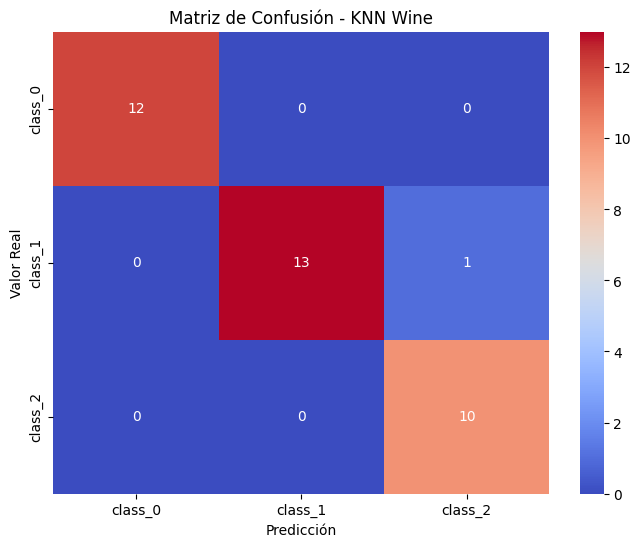


Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [7]:
# Evaluación detallada: Matriz de Confusión y Reporte de Clasificación
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="coolwarm", fmt="d",
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names)
plt.title("Matriz de Confusión - KNN Wine")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(y_test, predicciones, target_names=wine_data.target_names))

## Conclusiones

Durante la implementación de este laboratorio con el algoritmo K-Nearest Neighbors (KNN), se pueden destacar los siguientes hallazgos y decisiones:

1. **Importancia del Escalado:** Se tomó la decisión crítica de aplicar `StandardScaler` a los datos antes del entrenamiento. Debido a que KNN calcula las distancias (usualmente Euclidianas) entre los puntos de datos, las variables con escalas mayores habrían dominado injustamente la clasificación. El escalado permitió que todas las características aportaran de manera equitativa.
2. **Evaluación del Modelo:** El modelo demostró un excelente desempeño en la clasificación de las tres clases de vino, logrando un accuracy muy alto. Al revisar la matriz de confusión, se observa que la cantidad de falsos positivos y falsos negativos es mínima o nula, lo que indica que KNN es un algoritmo sumamente efectivo para las características fisicoquímicas presentes en este dataset.
3. **Estratificación:** Se decidió utilizar el parámetro `stratify=y` al momento de dividir los datos (`train_test_split`) para asegurar que tanto el conjunto de entrenamiento como el de pruebas tuvieran una representación justa de cada clase de vino, evitando sesgos durante el entrenamiento.